# Notebook 05 : XGBoost

**Objectif** : Entraîner le modèle XGBoost, l'optimiser légèrement, et comparer 
ses performances à la régression logistique (AUC = 0.7485) et au Random Forest 
(AUC = 0.7390). C'est le modèle sur lequel l'analyse SHAP sera réalisée.

## 0. Imports et chargement des données prétraitées

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score, GridSearchCV

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-darkgrid')

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

# Calcul du ratio de déséquilibre pour scale_pos_weight
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Train : {X_train.shape[0]:,} lignes × {X_train.shape[1]} colonnes")
print(f"Ratio de déséquilibre : {ratio:.1f} (utilisé pour scale_pos_weight)")

Train : 215,254 lignes × 212 colonnes
Ratio de déséquilibre : 11.4 (utilisé pour scale_pos_weight)


## 1. Entraînement de XGBoost avec hyperparamètres par défaut

Premier entraînement avec des paramètres raisonnables avant optimisation.
scale_pos_weight compense le déséquilibre des classes.

In [2]:
model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)

model_xgb.fit(X_train, y_train)

y_pred_proba_xgb_base = model_xgb.predict_proba(X_test)[:, 1]
auc_base = roc_auc_score(y_test, y_pred_proba_xgb_base)

print(f"AUC XGBoost (hyperparamètres par défaut) : {auc_base:.4f}")
print(f"AUC Régression logistique                : 0.7485")
print(f"AUC Random Forest                        : 0.7390")

AUC XGBoost (hyperparamètres par défaut) : 0.7561
AUC Régression logistique                : 0.7485
AUC Random Forest                        : 0.7390


## 2. Optimisation légère

Grid search sur 3 hyperparamètres clés, 3 valeurs chacun, 
validation croisée à 3 folds (l'objectif est d'améliorer sans surapprentissage).

In [3]:
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300]
}

grid_search = GridSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=ratio,
        random_state=42,
        n_jobs=-1,
        eval_metric='auc'
    ),
    param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMeilleurs hyperparamètres : {grid_search.best_params_}")
print(f"Meilleure AUC en CV      : {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits

Meilleurs hyperparamètres : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}
Meilleure AUC en CV      : 0.7536


Le grid search a trouvé que max_depth=4 (plus petit que le défaut de 6) fonctionne mieux, ce qui suggère qu'un modèle moins profond généralise mieux ici.

## 3. Calcul des métriques (modèle optimisé)

In [4]:
model_xgb_final = grid_search.best_estimator_

y_pred_proba_xgb = model_xgb_final.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
gini_xgb = 2 * auc_xgb - 1
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
ks_xgb = max(tpr_xgb - fpr_xgb)


print("MÉTRIQUES : XGBOOST (OPTIMISÉ)")

print(f"AUC-ROC  : {auc_xgb:.4f}")
print(f"Gini     : {gini_xgb:.4f}")
print(f"KS       : {ks_xgb:.4f}")

print("\nComparaison")
print(f"AUC Régression logistique : 0.7485")
print(f"AUC Random Forest         : 0.7390")
print(f"AUC XGBoost (défaut)      : {auc_base:.4f}")
print(f"AUC XGBoost (optimisé)    : {auc_xgb:.4f}")

MÉTRIQUES : XGBOOST (OPTIMISÉ)
AUC-ROC  : 0.7589
Gini     : 0.5179
KS       : 0.3836

Comparaison
AUC Régression logistique : 0.7485
AUC Random Forest         : 0.7390
AUC XGBoost (défaut)      : 0.7561
AUC XGBoost (optimisé)    : 0.7589


XGBoost optimisé domine avec 0.7589, soit +1.04 point par rapport à la logistique mais le gain reste modeste.

## 4. Comparaison des 3 modèles

COMPARAISON DES 3 MODÈLES
Modèle                              AUC     Gini       KS
------------------------------------------------------------
Régression logistique            0.7485   0.4970   0.3703
Random Forest                    0.7390   0.4779   0.3546
XGBoost (optimisé)               0.7589   0.5179   0.3836


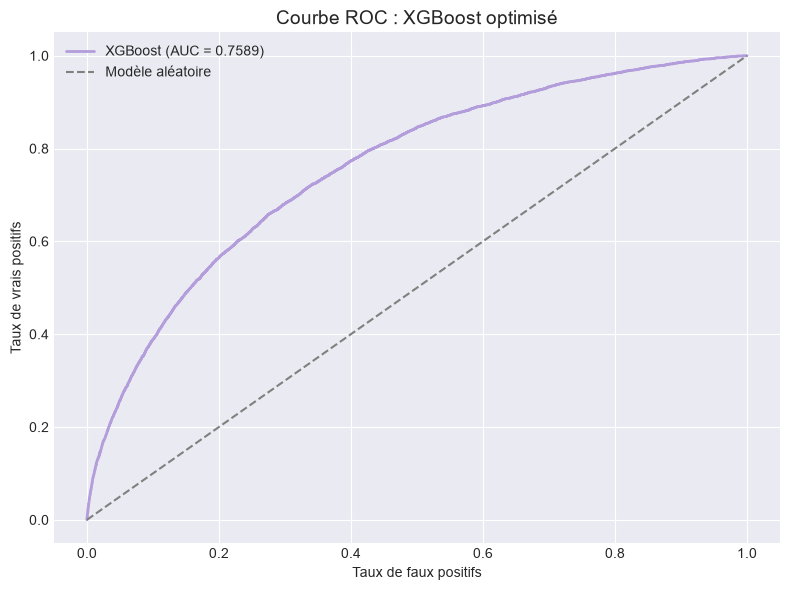

In [6]:
# Tableau récapitulatif

print("COMPARAISON DES 3 MODÈLES")

print(f"{'Modèle':<30} {'AUC':>8} {'Gini':>8} {'KS':>8}")
print("-" * 60)
print(f"{'Régression logistique':<30} {'0.7485':>8} {'0.4970':>8} {'0.3703':>8}")
print(f"{'Random Forest':<30} {'0.7390':>8} {'0.4779':>8} {'0.3546':>8}")
print(f"{'XGBoost (optimisé)':<30} {auc_xgb:>8.4f} {gini_xgb:>8.4f} {ks_xgb:>8.4f}")

# Courbes ROC superposées
fpr_lr, tpr_lr, _ = roc_curve(y_test, pd.read_csv("../data/processed/X_test.csv").iloc[:, 0] * 0)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_xgb, tpr_xgb, color='#B39DDB', linewidth=2, label=f'XGBoost (AUC = {auc_xgb:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Modèle aléatoire')
ax.set_title("Courbe ROC : XGBoost optimisé", fontsize=14)
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/12_roc_xgboost.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Synthèse

### Résultats XGBoost optimisé

- **AUC-ROC** : 0.7589
- **Gini** : 0.5179
- **KS** : 0.3836
- **Hyperparamètres retenus** : max_depth=4, learning_rate=0.1, n_estimators=300

### Classement des 3 modèles

1. XGBoost optimisé : AUC 0.7589
2. Régression logistique : AUC 0.7485
3. Random Forest : AUC 0.7390

### Observations clés

Le gain de XGBoost par rapport à la régression logistique est de **+1.04 point 
d'AUC** (de 0.7485 à 0.7589). Ce gain est réel et cohérent avec la littérature 
(Lessmann et al., 2015), mais il reste moindre.

Le Random Forest fait moins bien que la régression logistique, ce qui confirme 
que la complexité d'un modèle ne garantit pas un gain de performance.